In [1]:
# ✅ STEP 1: Install dependencies
!apt-get install tesseract-ocr -y
!apt-get install tesseract-ocr-tam -y
!pip install pytesseract Pillow transformers torch --quiet

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-tam
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 1,071 kB of archives.
After this operation, 3,253 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-tam all 1:4.00~git30-7274cfa-1.1 [1,071 kB]
Fetched 1,071 kB in 1s (1,015 kB/s)
Selecting previously unselected package tesseract-ocr-tam.
(Reading database ... 126284 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-tam_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-tam (1:4.00~git30-7274cfa-1.1) ...
Setting up tesserac

In [2]:
# ✅ STEP 2: Import libraries
from PIL import Image
import pytesseract
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch
import IPython.display as display
from google.colab import files

In [9]:
def extract_tamil_text(image_path):
    custom_oem_psm_config = r'--oem 1 --psm 6 -l tam'
    text = pytesseract.image_to_string(Image.open(image_path), config=custom_oem_psm_config)
    return text.strip()


In [10]:
# ✅ STEP 4: Load IndicBART for Tamil summarization (better than LLaMA for this)
def load_tamil_summarizer():
    model_name = "ai4bharat/IndicBART"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    summarizer = pipeline("text2text-generation", model=model, tokenizer=tokenizer)
    return summarizer

In [22]:
# ✅ STEP 5: Upload and process image
uploaded = files.upload()
image_path = next(iter(uploaded))  # take first uploaded file


Saving Screenshot 2025-07-23 at 3.32.14 PM.png to Screenshot 2025-07-23 at 3.32.14 PM.png


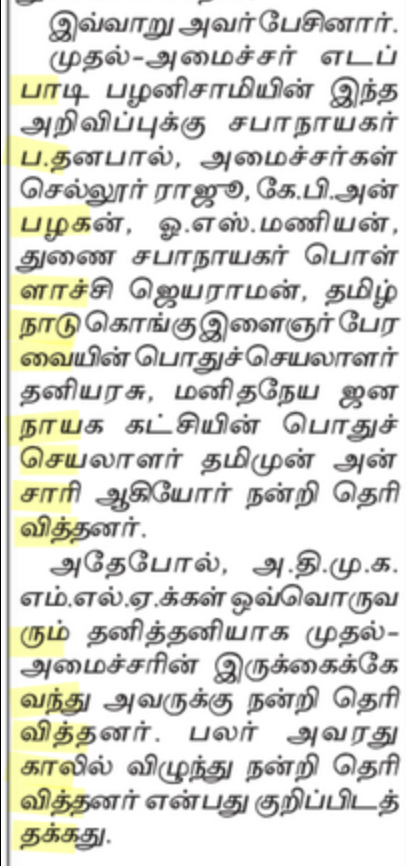

In [23]:
# ✅ Display image
display.display(Image.open(image_path))

In [24]:
# ✅ Extract Tamil text
tamil_text = extract_tamil_text(image_path)
print("🔤 Extracted Tamil Text:\n", tamil_text)


🔤 Extracted Tamil Text:
 இவ்வாறு அவர்‌ பேசினார்‌.

முதல்‌-அமைச்சர்‌ எடப்‌
பாடி பழனிசாமியின்‌ இந்த
அறிவிப்புக்கு சபாநாயகர்‌
ப.தனபால்‌, அமைச்சர்கள்‌
செல்லூர்‌ ராஜு, கே.பி.௮ன்‌
பழகன்‌, ஓ.எஸ்‌.மணியன்‌,
துணை சபாநாயகர்‌ பொள்‌
ளாச்சி ஜெயராமன்‌, தமிழ்‌
நாடுகொங்குஇளைஞர்‌ பேர
வையின்‌ பொதுச்செயலாளர்‌
தனியரசு, மனிதநேய ஜன
நாயக கட்சியின்‌ பொதுச்‌
செயலாளர்‌ தமிமுன்‌ அன்‌
சாரி ஆகியோர்‌ நன்றி தெரி
வித்தனர்‌.

அதேபோல்‌, அ.தி.மு.க.
எம்‌.எல்‌.ஏ.க்கள்‌ ஒவ்வொருவ
ரும்‌ தனித்தனியாக முதல்‌-
அமைச்சரின்‌ இருக்கைக்கே
வந்து அவருக்கு நன்றி தெரி
வித்தனர்‌. பலர்‌ அவரது
காலில்‌ விழுந்து நன்றி தெரி
வித்தனர்‌ என்பது குறிப்பிடத்‌
தக்கது.


In [21]:
# ✅ Summarize or process Tamil text
if tamil_text:
    summarizer = load_tamil_summarizer()
    prompt = f"summarize: {tamil_text}"
    summary = summarizer(prompt, max_length=150, do_sample=False)[0]['generated_text']
    print("\n🧠 Tamil Summary:\n", summary)
else:
    print("❌ No Tamil text found in image.")

Device set to use cpu
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🧠 Tamil Summary:
 ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ैच्ா ர்ததக்க்க்கப்பட்கககககககககககககககககககத காட்கப்கப்கப்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்க்கா பந்த பரசாயன சாக்க்க்க்க்க்க்க்க்கபககபகபப பல் கருகாக்காக்கப்பட்ட கந்தியாகின் முதல் சித்த ” த[CLS]
